# Домашнее задание 2

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly as pl
import seaborn as sns

# Table of Contents

1. [Загрузка данных и первичный осмотр](#загрузка-данных-и-первичный-осмотр)
2. [Обработка данных](#обработка-данных)
3. [Базовые EDA](#базовые-eda)
4. [Визуализация данных в Matplotlib](#визуализация-данных-в-matplotlib)



# Загрузка данных и первичный осмотр

In [34]:
df = pd.read_csv("S02-hw-dataset.csv")
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [35]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [36]:
df.describe(include=object)

,country
count,41
unique,5
top,RU
freq,13


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


В датасете у нас 1 категориальный признак - страна, один с плавающей точкой, остальные признаки являются целочисленными. 

В колонке возраст есть два пропуска. user_id - уникальный id для строчек. В purchases - покупки - есть отрицательные значения - возможно ошибка в данных. revenue - доход. В данных 5 странн -  самая популярная Россия.

# Обработка данных

In [38]:
df[df.duplicated()]

,user_id,age,country,purchases,revenue
40,10,24.0,RU,7,511


In [39]:
if df.duplicated().sum() > 0:
    df.drop_duplicates()


В данных был найден один дубликат. Удаляем его.

In [40]:
for col in df.columns:
    print (col, df[col].isna().sum())

user_id 0
age 2
country 0
purchases 0
revenue 0


In [41]:
df[df.isnull().any(axis=1)]

,user_id,age,country,purchases,revenue
4,5,NaN,DE,6,1296
12,13,NaN,US,9,630


Есть две строчки с пропусками - можно попробовать заменить их медианой по, например, стране (взять средний возраст каждой страны)

In [42]:
df['age']=df['age'].fillna(df.groupby('country')['age'].transform('mean'))


Реализуем фильтры для нашего датасета. Например, поставим, что значения не могут быть отрицательными. Уберем весь возраст > 130, а также нулевой доход при ненулевых продажах.

In [43]:
mask_age = (df.age < 0) | (df.age > 130)
mask_purchases = ((df.purchases > 0) & (df.revenue <= 0)) | (df.purchases < 0) | (df.revenue < 0) 
mask = mask_age | mask_purchases
df = df.where(~mask) 

Все сомнительные значения были заменены на nan. Теперь нужно их отфильтровать, предлагаю их просто удалить.

In [44]:
df = df.dropna()

In [45]:
df.isna().sum()

user_id      0
age          0
country      0
purchases    0
revenue      0
dtype: int64

Были удалены значения, которые не подходят с точки зрения точности, скорее всего они являлись ошибочными, так как у нас не может быть отрицательная выручка, так же были удалены дубликаты и заменены nan значения.

# Базовые EDA

In [46]:
group=df.groupby('country')
group.size()

country
CN     2
DE     6
FR    11
RU    13
US     7
dtype: int64

In [47]:
df['mean_purchase_by_country'] = df.groupby(["country"])["purchases"].transform('mean')
df['max_age_by_country'] = df.groupby(["country"])["age"].transform('max')
df["revenue_std_by_country"] = df.groupby(['country'])["revenue"].transform("std")
df['level_revenue']=pd.cut(df['revenue'], 3,labels=['Low','Medium','High'], include_lowest=True)
df['level_revenue'] = df['level_revenue'].astype('object')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,39.0,20.846154,11.624698,1.000000,11.000000,21.000000,30.500000,40.00000
age,39.0,34.649084,12.001421,5.000000,24.500000,34.000000,44.000000,57.00000
purchases,39.0,5.000000,2.605662,0.000000,3.000000,6.000000,7.000000,11.00000
revenue,39.0,841.974359,614.400542,0.000000,437.000000,693.000000,1138.500000,2475.00000
mean_purchase_by_country,39.0,5.000000,0.650545,4.500000,4.727273,4.727273,4.769231,6.50000
max_age_by_country,39.0,52.666667,6.216842,28.000000,52.000000,54.000000,57.000000,57.00000
revenue_std_by_country,39.0,563.246309,168.325384,271.908686,533.463026,599.300629,599.300629,845.69971


In [48]:
df.describe(include="object")

,country,level_revenue
count,39,39
unique,5,3
top,RU,Low
freq,13,23


Я добавила 4 столбца-агрегации, они основаны на категориальном столбце страны. Были посчитаны среднее, максимум стандартное отклонение. Так же столбец прибыль был поделен на три уровня - маленький доход, средний и высокий (было реализовано как дополнительный столбец). Так как это итоговый столбец с признаками - сохраним его. Можно было бы добавить больше признаков, сделать отбор признаков.

О данных - максимальный возраст везде примерно 55 лет. В данных осталось 39 строчек. У столбца прибыль очень большое стандартное отклонение. В основном у стран низкий доход (23 из 39!!!). В среднем в каждой операции одинаковое количество купленного товара. В целом, данные однородные, нет явных выбросов.

In [49]:
df.to_csv('data_feature.csv')

# Визуализация данных в Matplotlib

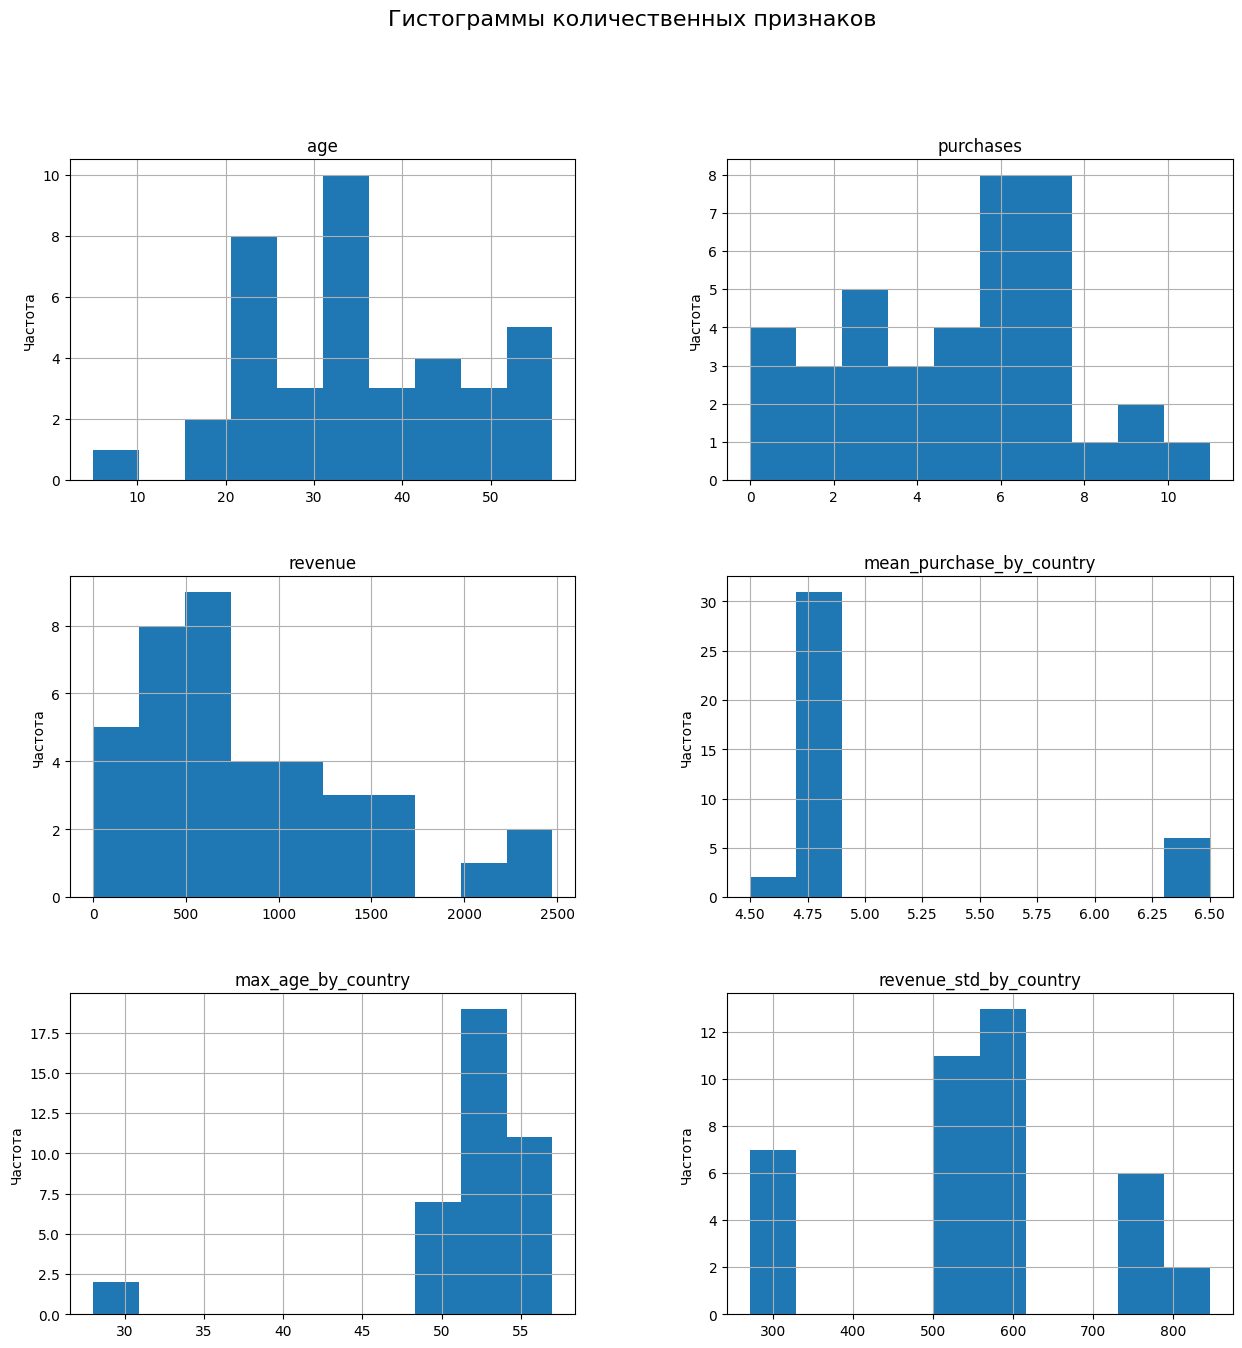

In [50]:
cols = (df.select_dtypes(include=['number']).columns).drop("user_id")
fig1 = df[cols].hist(bins=10, figsize=(15,15))

plt.suptitle("Гистограммы количественных признаков", fontsize=16)

for ax in fig1.flatten():
    ax.set_ylabel(ax.get_ylabel() or "Частота")

plt.savefig('figures/histograms.png', dpi=300)
plt.show()

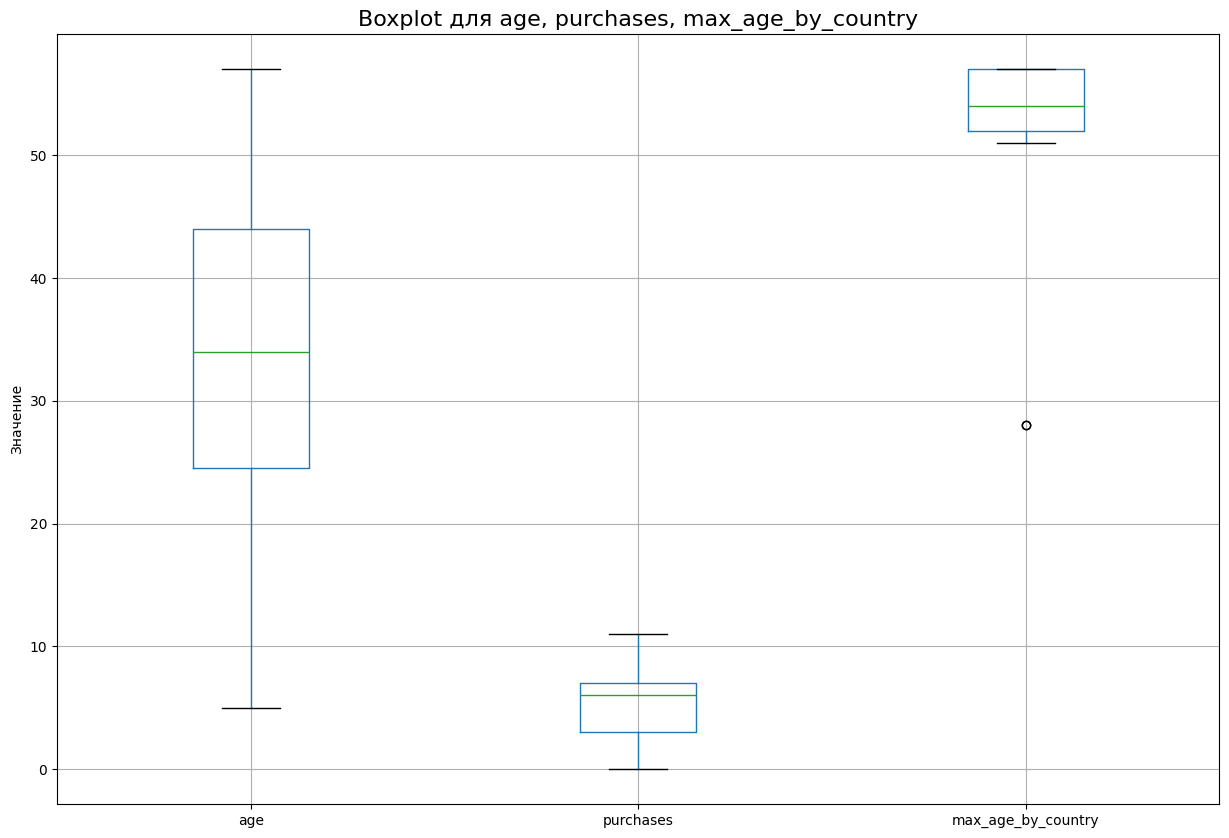

In [51]:
fig2, ax2 = plt.subplots(figsize=(15, 10))
df.boxplot(column=['age', 'purchases', 'max_age_by_country'], ax=ax2)
ax2.set_title("Boxplot для age, purchases, max_age_by_country", fontsize=16)
ax2.set_ylabel("Значение")
plt.savefig('figures/boxplot.png', dpi=300)
plt.show()

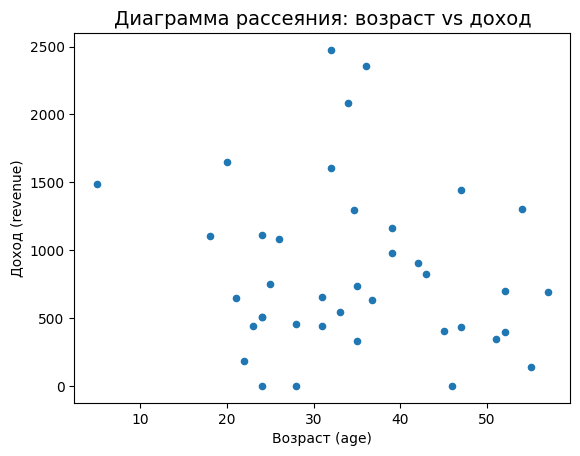

In [52]:
fig3, ax3 = plt.subplots()
df.plot.scatter(x='age', y='revenue', ax=ax3)
ax3.set_title("Диаграмма рассеяния: возраст vs доход", fontsize=14)
ax3.set_xlabel("Возраст (age)")
ax3.set_ylabel("Доход (revenue)")
plt.savefig('figures/scatter_age_revenue.png', dpi=300)
plt.show()

### Выводы по блоку: 
Наибольший доход у людей возраста 30-40 лет (видно по диаграмме рассеевания). У всех колонок, кроме возраст и кол-во покупок, много выбросов, видно на ящике с усами (где совсем много выбрасов, я убрала, так как тяжело смотреть картинку, она растягивается.)

У одной страны максимальный возраст в районе 30, у остальных это в среднем 55 лет. У одной страны среднее кол-ко покупок > 6, у остальных в районе 4,5 - 4,75.

В данных нет людей с 10 до 15 лет, а стандартное отклонение дохода поделилось на три группы  - низкое, среднее и большое.